In [1]:
# Importing the dependent modules
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
iris = load_iris()

In [3]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
%matplotlib inline

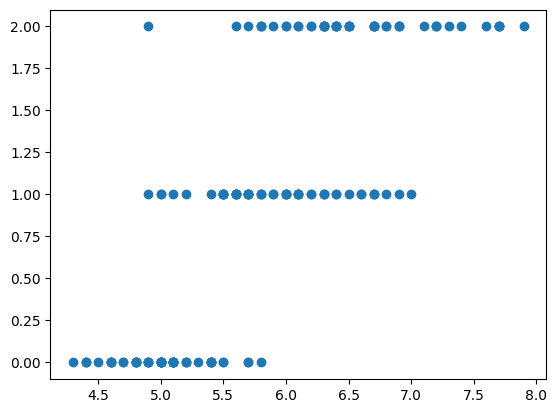

In [10]:
# Visualize the data
plt.scatter(df["sepal length (cm)"], iris.target)

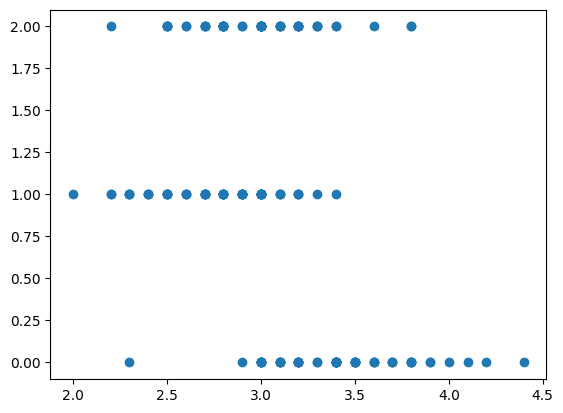

In [11]:
plt.scatter(df["sepal width (cm)"], iris.target)

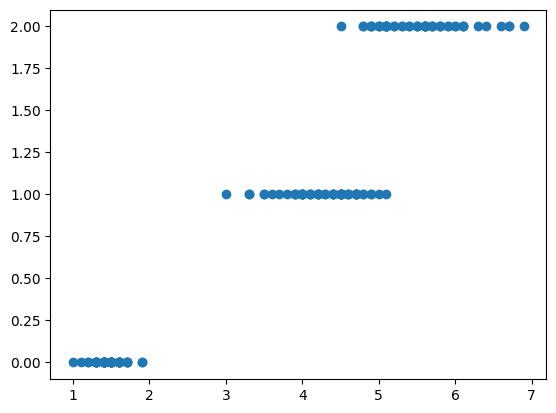

In [12]:
plt.scatter(df["petal length (cm)"], iris.target)

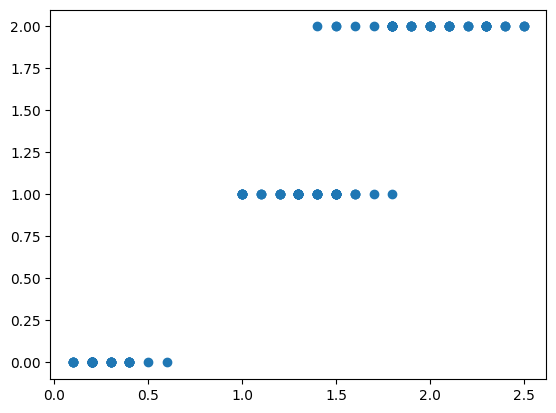

In [13]:
plt.scatter(df["petal width (cm)"], iris.target)

In [14]:
# Identify number of clusters using elbow
k_range = range(1,10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "sepal width (cm)"]])
    sse.append(km.inertia_) # inertia_ is the sum square error

In [15]:
sse

[623.1075999999999,
 153.24614379084971,
 84.74620272840016,
 64.26936515151513,
 54.78443620689656,
 48.330249194068344,
 39.781540371393326,
 34.54814682539683,
 33.15273235691038]

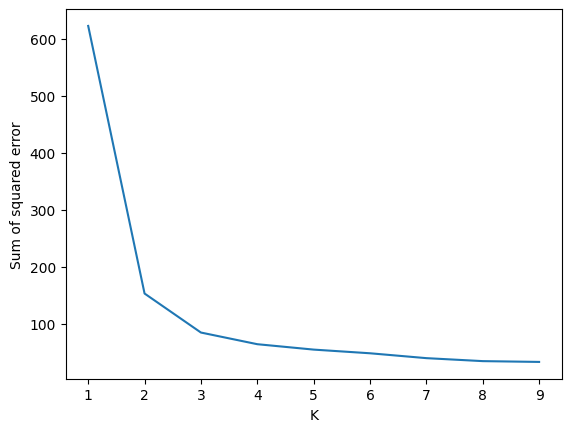

In [16]:
# Create a elbow graph
plt.xlabel("K")
plt.ylabel("Sum of squared error")
plt.plot(k_range, sse)

In [19]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [21]:
y_predicted = km.fit_predict(df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "sepal width (cm)"]])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [22]:
df["predicted"] = y_predicted
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predicted
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [27]:
# df1 = df[df.predicted==0]
# df2 = df[df.predicted==1]
# df3 = df[df.predicted==3]
# plt.scatter(df1[["sepal length (cm)" ,"sepal width (cm)", "petal length (cm)", "petal width (cm)"]], df1["predicted"], color="red")
# plt.scatter(df2[["sepal length (cm)" ,"sepal width (cm)", "petal length (cm)", "petal width (cm)"]], df2["predicted"], color="green")
# plt.scatter(df3[["sepal length (cm)" ,"sepal width (cm)", "petal length (cm)", "petal width (cm)"]], df3["predicted"], color="blue")
# # plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color="purple", marker="*", label="centroid")
# plt.xlabel("Chars")
# plt.ylabel("Predicted")
# plt.legend()

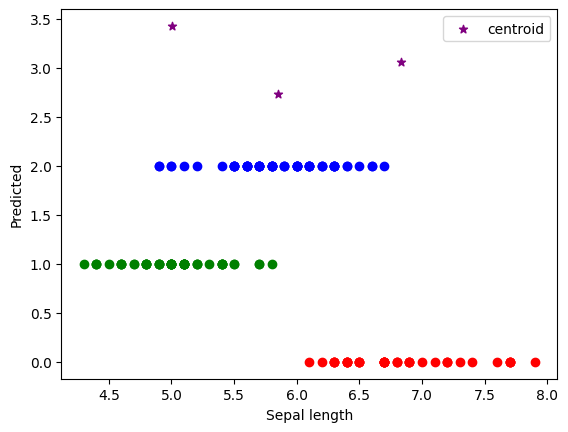

In [29]:
# Plot again based on group
df1 = df[df.predicted==0]
df2 = df[df.predicted==1]
df3 = df[df.predicted==2]
plt.scatter(df1["sepal length (cm)"], df1["predicted"], color="red")
plt.scatter(df2["sepal length (cm)"], df2["predicted"], color="green")
plt.scatter(df3["sepal length (cm)"], df3["predicted"], color="blue")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color="purple", marker="*", label="centroid")
plt.xlabel("Sepal length")
plt.ylabel("Predicted")
plt.legend()